# Project 2: Customer Segmentation Analysis
**Oasis Infobyte - Level 1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries ready!')

Libraries ready!


## Step 1: Load Dataset

In [2]:
np.random.seed(42)
n = 500
df = pd.DataFrame({
    'CustomerID': range(1, n+1),
    'Age': np.random.randint(18, 70, n),
    'Annual_Income': np.random.randint(15000, 150000, n),
    'Purchase_Frequency': np.random.randint(1, 50, n),
    'Avg_Order_Value': np.round(np.random.uniform(200, 20000, n), 2),
    'Days_Since_Last_Purchase': np.random.randint(1, 365, n),
    'Total_Spend': np.round(np.random.uniform(500, 500000, n), 2)
})
df.loc[np.random.choice(df.index,15), 'Annual_Income'] = np.nan
print('Shape:', df.shape)
df.head()

Shape: (500, 7)


,CustomerID,Age,Annual_Income,Purchase_Frequency,Avg_Order_Value,Days_Since_Last_Purchase,Total_Spend
0,1,56,149415.0,5,890.33,58,83064.41
1,2,69,44375.0,20,17919.44,259,350275.85
2,3,46,31964.0,11,17230.51,342,293112.17
3,4,32,128429.0,10,9257.16,326,293446.31
4,5,60,82215.0,40,7945.16,130,348986.48


## Step 2: Clean & Scale Data

In [3]:
df['Annual_Income'].fillna(df['Annual_Income'].median(), inplace=True)
features = ['Annual_Income','Purchase_Frequency','Avg_Order_Value','Days_Since_Last_Purchase','Total_Spend']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Data cleaned and scaled!')
print('Missing values:', df.isnull().sum().sum())

Data cleaned and scaled!
Missing values: 0


## Step 3: Find Optimal K (Elbow Method)

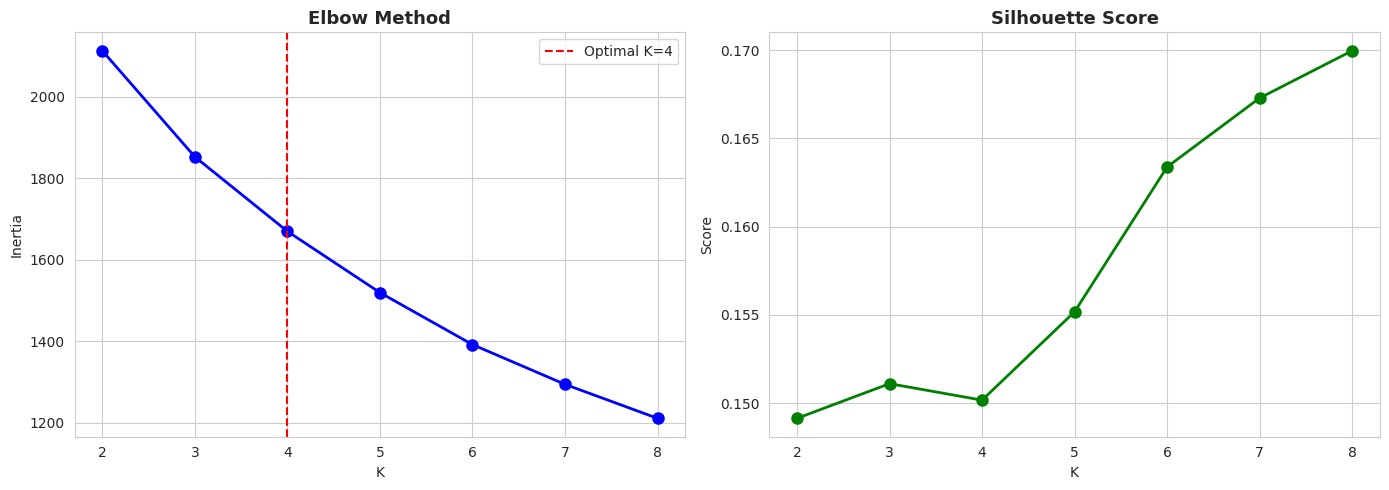

Best K: 8


In [4]:
inertias, scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
axes[0].legend()
axes[1].plot(K_range, scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
plt.tight_layout(); plt.show()
print(f'Best K: {list(K_range)[scores.index(max(scores))]}')

## Step 4: Apply KMeans & Visualize

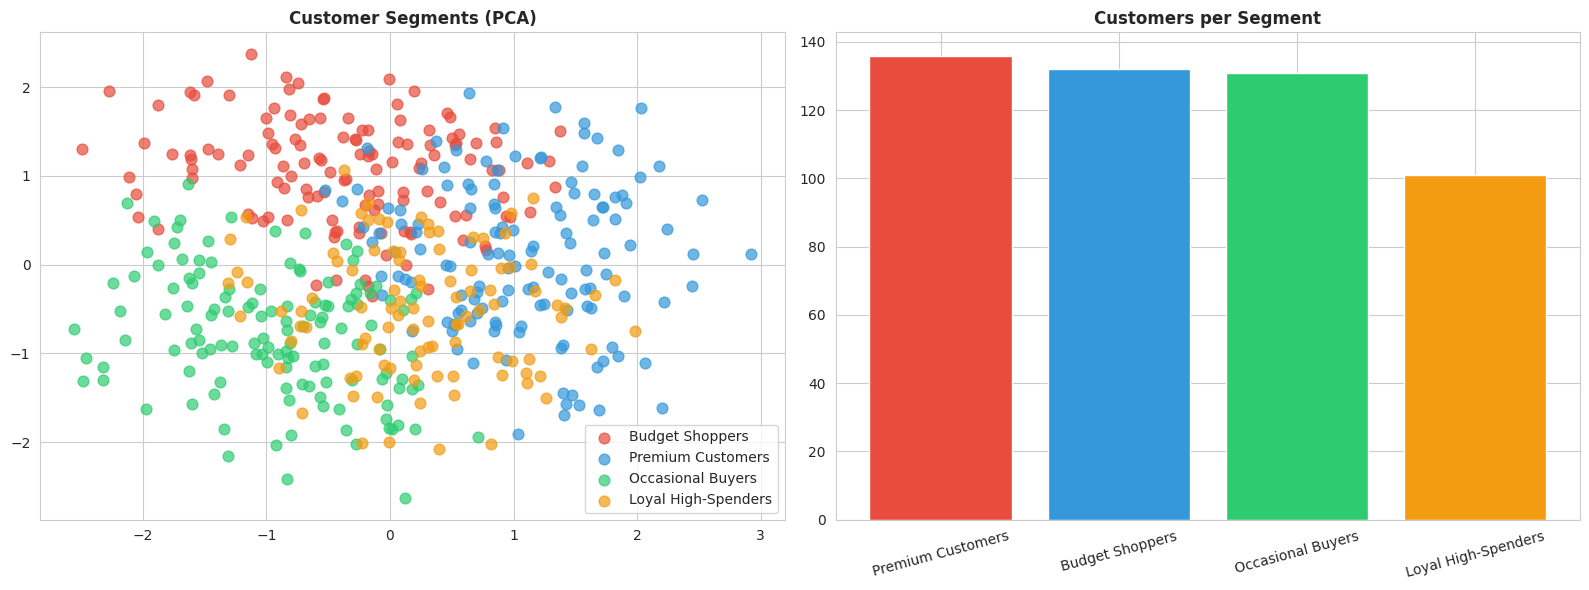

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
labels = {0:'Budget Shoppers', 1:'Premium Customers', 2:'Occasional Buyers', 3:'Loyal High-Spenders'}
df['Segment'] = df['Cluster'].map(labels)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12']
for i, (c, label) in enumerate(labels.items()):
    mask = df['Cluster'] == c
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], c=colors[i], label=label, alpha=0.7, s=60)
axes[0].set_title('Customer Segments (PCA)', fontweight='bold')
axes[0].legend()

seg_cnt = df['Segment'].value_counts()
axes[1].bar(seg_cnt.index, seg_cnt.values, color=colors)
axes[1].set_title('Customers per Segment', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

## Step 5: Segment Profiles & Recommendations

In [6]:
profile = df.groupby('Segment')[features].mean().round(2)
print('=== Segment Profiles ===')
print(profile.to_string())
print()
print('=== Recommendations ===')
print('Budget Shoppers      -> Offer discounts and flash sales')
print('Premium Customers    -> Exclusive products and early access')
print('Occasional Buyers    -> Re-engagement email campaigns')
print('Loyal High-Spenders  -> VIP loyalty rewards program')

=== Segment Profiles ===
                     Annual_Income  Purchase_Frequency  Avg_Order_Value  Days_Since_Last_Purchase  Total_Spend
Segment                                                                                                       
Budget Shoppers           62757.39               27.89          9267.01                    293.92    278148.62
Loyal High-Spenders       66641.37               39.94          8764.72                    100.52    217028.61
Occasional Buyers         68772.54               11.70          8040.27                    115.18    256100.78
Premium Customers        122237.65               27.68         14088.80                    185.50    231800.14

=== Recommendations ===
Budget Shoppers      -> Offer discounts and flash sales
Premium Customers    -> Exclusive products and early access
Occasional Buyers    -> Re-engagement email campaigns
Loyal High-Spenders  -> VIP loyalty rewards program
